#  Activations

A function applied to weighted sum of inputs which introduces non-linearity and decides whether a neuron fires or dead.

Fires or dead here means whether it passes its signal forward to the next layer or block it.

In [1]:
import numpy as np
rng = np.random.default_rng(7)
from typing import Optional

In [2]:
import sys
print(sys.executable)

c:\Users\USER\Desktop\projects\sandhorse-tinytorch\.venv\Scripts\python.exe


In [3]:
from tinytorch.core.tensor import Tensor

print(Tensor)

<class 'tinytorch.core.tensor.Tensor'>


In [4]:
# Constants for numerical comparisons
TOLERANCE = 1e-10  # Small tolerance for floating-point comparisons in tests

# Export only activation classes
__all__ = ['Sigmoid', 'ReLU', 'Tanh', 'GELU', 'Softmax']

### - Implementation Pattern

Each activation follows this structure:

```python
class ActivationName:
    def forward(self, x: Tensor) -> Tensor:
        # Apply math transformation
        # Return new Tensor with result
```

## Sigmoid

It maps any real number to the range(0, 1), making it perfect for probabilities and binary decisions.


Given the input tensor $\mathbf{x}$:
$$
\mathbf{x} = \begin{bmatrix} -3 & -1 & 0 & 1 & 3 \end{bmatrix}
$$

Applying the sigmoid function $\sigma(x) = \frac{1}{1 + e^{-x}}$ element-wise:
$$
\sigma(\mathbf{x}) = \begin{bmatrix} 
\frac{1}{1 + e^{3}} & \frac{1}{1 + e^{1}} & \frac{1}{1 + e^{0}} & \frac{1}{1 + e^{-1}} & \frac{1}{1 + e^{-3}} 
\end{bmatrix}
$$

The resulting output probabilities (rounded to four decimal places) are:
$$
\mathbf{y} \approx \begin{bmatrix} 0.0474 & 0.2689 & 0.5000 & 0.7311 & 0.9526 \end{bmatrix}
$$


![Sigmoid Curve](sigmoid_curve.png)

#### 1. Implement Sigmoid Function

> APPROACH

- Apply sigmoid formula
- Use `np.exp` for exponential
- Return result wrapped in new tensor


In [5]:
class Sigmoid:
    def parameters(self):
        return []
    def forward(self, x: Tensor) -> Tensor:
        """Apply the sigmoid function elementwise to the input tensor."""
        x_data = x.data
        with np.errstate(over='ignore', invalid='ignore'):
            result = np.where(
                x_data >= 0,
                1.0 / (1.0 + np.exp(-x_data)),
                np.exp(x_data) / (1.0 + np.exp(x_data))
            )
        return Tensor(result)

In [6]:
sigmoid = Sigmoid()
x = Tensor([-2, 0, 2])
result = sigmoid.forward(x)
print(result)

Tensor([0.11920292 0.5        0.880797  ])


### - SIGMOID UNIT TEST

This test validates sigmoid activation behavior

- `WHAT:` To Simoid maps inputs to output range (0, 1)

- `WHY:` Ensures proper probability outputs

- `EXPECTED:` All ouputs between 0 amd 1, sigmoid(0) = 0.5 



In [7]:
def test_unit_sigmoid():
    """🧪 Test Sigmoid implementation."""
    print("🧪 Unit Test: Sigmoid...")

    sigmoid = Sigmoid()

    # Test basic cases
    x = Tensor([0.0])
    result = sigmoid.forward(x)
    assert np.allclose(result.data, [0.5]), f"sigmoid(0) should be 0.5, got {result.data}"

    # Test range property - all outputs should be in (0, 1)
    x = Tensor([-10, -1, 0, 1, 10])
    result = sigmoid.forward(x)
    assert np.all(result.data > 0) and np.all(result.data < 1), "All sigmoid outputs should be in (0, 1)"

    # Test extreme values: the stable form must stay finite without overflow.
    x = Tensor([-1000, 1000])  # Extreme values
    result = sigmoid.forward(x)
    assert np.allclose(result.data[0], 0, atol=TOLERANCE), "sigmoid(-∞) should approach 0"
    assert np.allclose(result.data[1], 1, atol=TOLERANCE), "sigmoid(+∞) should approach 1"

    print("✅ Sigmoid works correctly!")

if __name__ == "__main__":
    test_unit_sigmoid()

🧪 Unit Test: Sigmoid...
✅ Sigmoid works correctly!


## ReLU

ReLU (Rectified Linear Unit) is a function that returns 0 for any -ve input and leaves +ve positive inputs unchanged.


### f(x) = max(0, x)

WHY ReLU? By zeroing -ve values, ReLU creates sparsity(many zeros) which makes computation faster and helps prevent overfitting.

### 2. Implement ReLU function

APPROACH:

- Use `np.maximum(0, x.data)` for element-wise max zero

- Return result wrapped in new Tensor


In [8]:
class ReLU:
    def parameters(self):
        """Return empty list (activations have no learnable parameters)"""
        return []
    def forward(self, x: Tensor) -> Tensor:
        """Apply the ReLU function elementwise to the input tensor."""
        result = np.maximum(0, x.data)
        return Tensor(result)
    def __call__(self, x: Tensor) -> Tensor:
        """Allow the ReLU instance to be called like a function."""
        return self.forward(x)

In [9]:
relu = ReLU()
x = Tensor([-2, -1, 0, 1, 2])
result = relu.forward(x)
print(result)

Tensor([0. 0. 0. 1. 2.])


### - ReLU UNIT TEST

In [10]:
def test_unit_relu():
    """🧪 Test ReLU implementation."""
    print("🧪 Unit Test: ReLU...")

    relu = ReLU()

    # Test mixed positive/negative values
    x = Tensor([-2, -1, 0, 1, 2])
    result = relu.forward(x)
    expected = [0, 0, 0, 1, 2]
    assert np.allclose(result.data, expected), f"ReLU failed, expected {expected}, got {result.data}"

    # Test all negative
    x = Tensor([-5, -3, -1])
    result = relu.forward(x)
    assert np.allclose(result.data, [0, 0, 0]), "ReLU should zero all negative values"

    # Test all positive
    x = Tensor([1, 3, 5])
    result = relu.forward(x)
    assert np.allclose(result.data, [1, 3, 5]), "ReLU should preserve all positive values"

    # Test sparsity property
    x = Tensor([-1, -2, -3, 1])
    result = relu.forward(x)
    zeros = np.sum(result.data == 0)
    assert zeros == 3, f"ReLU should create sparsity, got {zeros} zeros out of 4"

    print("✅ ReLU works correctly!")

if __name__ == "__main__":
    test_unit_relu()


🧪 Unit Test: ReLU...
✅ ReLU works correctly!


## Tanh

Tanh (Hyberbolic tangent) is a function that takes any real number and squeezes it into a value between - 1 and +1

**Why Tanh?** Unlike Sigmoid, tanh outputs are centered around zero, which is a desirable property for composing multiple transformations.

In [11]:
class Tanh:
    def parameters(self):
        """Return empty list (activations have no learnable parameters)"""
        return []
    def forward(self, x: Tensor) -> Tensor:
        result = np.tanh(x.data)
        return Tensor(result)
    def __call__(self, x: Tensor) -> Tensor:
        """Allow the Tanh instance to be called like a function."""
        return self.forward(x)

In [12]:
tanh = Tanh()
x = Tensor([-2, 0, 2])
result = tanh.forward(x)
print(result.data)

[-0.9640276  0.         0.9640276]


In [13]:
def test_unit_tanh():
    """🧪 Test Tanh implementation."""
    print("🧪 Unit Test: Tanh...")

    tanh = Tanh()

    # Test zero
    x = Tensor([0.0])
    result = tanh.forward(x)
    assert np.allclose(result.data, [0.0]), f"tanh(0) should be 0, got {result.data}"

    # Test range property - all outputs should be in (-1, 1)
    x = Tensor([-10, -1, 0, 1, 10])
    result = tanh.forward(x)
    assert np.all(result.data >= -1) and np.all(result.data <= 1), "All tanh outputs should be in [-1, 1]"

    # Test symmetry: tanh(-x) = -tanh(x)
    x = Tensor([2.0])
    pos_result = tanh.forward(x)
    x_neg = Tensor([-2.0])
    neg_result = tanh.forward(x_neg)
    assert np.allclose(pos_result.data, -neg_result.data), "tanh should be symmetric: tanh(-x) = -tanh(x)"

    # Test extreme values
    x = Tensor([-1000, 1000])
    result = tanh.forward(x)
    assert np.allclose(result.data[0], -1, atol=TOLERANCE), "tanh(-∞) should approach -1"
    assert np.allclose(result.data[1], 1, atol=TOLERANCE), "tanh(+∞) should approach 1"

    print("✅ Tanh works correctly!")

if __name__ == "__main__":
    test_unit_tanh()

🧪 Unit Test: Tanh...
✅ Tanh works correctly!


## GELU (Gaussain Error Linear Unit)

A SoTA function that scales input by the cummulative distribution function of the standard normal distribution.

It is a smooth approximation of ReLU and it is popular in modern architectures like transformers.

`WHY GELU?` It is used in GPT, BERT, and other modern architectures. The smoothness helps with optimization compared to ReLU's sharp corner.



### - Implentation of GELU Approximation

> APPROACH

- Use approximation: `x*Sigmoid(1.702*x)

- Compute sigmoid part: 1/(1 + exp(-1.702*x))

- Multiply by x element - wise

- Return result wrapped in new tensor

In [14]:
class GELU:
    def parameters(self):
        """Return empty list (activations have no learnable parameters)"""
        return []
    def forward(self, x: Tensor) -> Tensor:
        """Apply the GELU function elementwise to the input tensor."""
        return sigmoid.forward(x*1.702)*x
    def __call__(self, x: Tensor) -> Tensor:
        """Allow the GELU instance to be called like a function."""
        return self.forward(x)

In [15]:
gelu = GELU()
x = Tensor([-1, 0, 1])
result = gelu(x)
print(result.data)

[-0.15420423  0.          0.8457958 ]


 ### - UNIT TEST

In [16]:
def test_unit_gelu():
    """🧪 Test GELU implementation."""
    print("🧪 Unit Test: GELU...")

    gelu = GELU()

    # Test zero (should be approximately 0)
    x = Tensor([0.0])
    result = gelu.forward(x)
    assert np.allclose(result.data, [0.0], atol=TOLERANCE), f"GELU(0) should be ≈0, got {result.data}"

    # Test positive values (should be roughly preserved)
    x = Tensor([1.0])
    result = gelu.forward(x)
    assert result.data[0] > 0.8, f"GELU(1) should be ≈0.84, got {result.data[0]}"

    # Test negative values (should be small but not zero)
    x = Tensor([-1.0])
    result = gelu.forward(x)
    assert result.data[0] < 0 and result.data[0] > -0.2, f"GELU(-1) should be ≈-0.16, got {result.data[0]}"

    # Test smoothness property (no sharp corners like ReLU)
    x = Tensor([-0.001, 0.0, 0.001])
    result = gelu.forward(x)
    # Values should be close to each other (smooth)
    diff1 = abs(result.data[1] - result.data[0])
    diff2 = abs(result.data[2] - result.data[1])
    assert diff1 < 0.01 and diff2 < 0.01, "GELU should be smooth around zero"

    print("✅ GELU works correctly!")

if __name__ == "__main__":
    test_unit_gelu()

🧪 Unit Test: GELU...
✅ GELU works correctly!


### SoftMax

A function that converts any vector into a valid probability distribution.

WHY SOFTMAX? In multi-class classification, we need outputs that represent probabilities for each class. SoftMax gives valid probabilities

In [17]:
class Softmax:
    def parameters(self):
        """Return empty list (activations have no learnable parameters)"""
        return []
    def forward(self, x: Tensor, dim=-1) -> Tensor:
        """Apply the softmax function to the input tensor along the specified axis."""
        # Subtract max for numerical stability
        x_max = np.max(x.data, axis=dim, keepdims=True)       
        x_shifted = x.data - x_max

        # compute exponentials  
        exp_values = np.exp(x_shifted)

        # suum along dimension
        exp_sum = np.sum(exp_values, axis=dim, keepdims=True)

        # Normalize to get probabilities
        result = exp_values / exp_sum
        return Tensor(result)
    
    def __call__(self, x: Tensor, dim=-1) -> Tensor:
        """Allow the Softmax instance to be called like a function."""
        return self.forward(x, dim=dim)

In [18]:
softmax = Softmax()
x = Tensor([1, 2, 3])
result = softmax.forward(x)
print(result.data)

[0.09003057 0.24472846 0.66524094]


In [19]:
def test_unit_softmax():
    """🧪 Test Softmax implementation."""
    print("🧪 Unit Test: Softmax...")

    softmax = Softmax()

    # Test basic probability properties
    x = Tensor([1, 2, 3])
    result = softmax.forward(x)

    # Should sum to 1
    assert np.allclose(np.sum(result.data), 1.0), f"Softmax should sum to 1, got {np.sum(result.data)}"

    # All values should be positive
    assert np.all(result.data > 0), "All softmax values should be positive"

    # All values should be less than 1
    assert np.all(result.data < 1), "All softmax values should be less than 1"

    # Largest input should get largest output
    max_input_idx = np.argmax(x.data)
    max_output_idx = np.argmax(result.data)
    assert max_input_idx == max_output_idx, "Largest input should get largest softmax output"

    # Test numerical stability with large numbers
    x = Tensor([1000, 1001, 1002])  # Would overflow without max subtraction
    result = softmax.forward(x)
    assert np.allclose(np.sum(result.data), 1.0), "Softmax should handle large numbers"
    assert not np.any(np.isnan(result.data)), "Softmax should not produce NaN"
    assert not np.any(np.isinf(result.data)), "Softmax should not produce infinity"

    # Test with 2D tensor (batch dimension)
    x = Tensor([[1, 2], [3, 4]])
    result = softmax.forward(x, dim=-1)  # Softmax along last dimension
    assert result.shape == (2, 2), "Softmax should preserve input shape"
    # Each row should sum to 1
    row_sums = np.sum(result.data, axis=-1)
    assert np.allclose(row_sums, [1.0, 1.0]), "Each row should sum to 1"

    print("✅ Softmax works correctly!")

if __name__ == "__main__":
    test_unit_softmax()

🧪 Unit Test: Softmax...
✅ Softmax works correctly!


## 🧪 Module Integration Test

In [20]:
def test_module():
    """🧪 Module Test: Complete Integration

    Comprehensive test of entire module functionality.

    This final test runs before module summary to ensure:
    - All unit tests pass
    - Functions work together correctly
    - Module is ready for integration with TinyTorch
    """
    print("🧪 RUNNING MODULE INTEGRATION TEST")
    print("=" * 50)

    # Run all unit tests
    print("Running unit tests...")
    test_unit_sigmoid()
    test_unit_relu()
    test_unit_tanh()
    test_unit_gelu()
    test_unit_softmax()

    print("\nRunning integration scenarios...")

    # Test 1: All activations preserve tensor properties
    print("🧪 Integration Test: Tensor property preservation...")
    test_data = Tensor([[1, -1], [2, -2]])  # 2D tensor

    activations = [Sigmoid(), ReLU(), Tanh(), GELU()]
    for activation in activations:
        result = activation.forward(test_data)
        assert result.shape == test_data.shape, f"Shape not preserved by {activation.__class__.__name__}"
        assert isinstance(result, Tensor), f"Output not Tensor from {activation.__class__.__name__}"

    print("✅ All activations preserve tensor properties!")

    # Test 2: Softmax works with different dimensions
    print("🧪 Integration Test: Softmax dimension handling...")
    data_3d = Tensor([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])  # (2, 2, 3)
    softmax = Softmax()

    # Test different dimensions
    result_last = softmax(data_3d, dim=-1)
    assert result_last.shape == (2, 2, 3), "Softmax should preserve shape"

    # Check that last dimension sums to 1
    last_dim_sums = np.sum(result_last.data, axis=-1)
    assert np.allclose(last_dim_sums, 1.0), "Last dimension should sum to 1"

    print("✅ Softmax handles different dimensions correctly!")

    # Test 3: Activation chaining (simulating neural network)
    print("🧪 Integration Test: Activation chaining...")

    # Simulate: Input → Linear → ReLU → Linear → Softmax (like a simple network)
    x = Tensor([[-1, 0, 1, 2]])  # Batch of 1, 4 features

    # Apply ReLU (hidden layer activation)
    relu = ReLU()
    hidden = relu.forward(x)

    # Apply Softmax (output layer activation)
    softmax = Softmax()
    output = softmax.forward(hidden)

    # Verify the chain
    assert hidden.data[0, 0] == 0, "ReLU should zero negative input"
    assert np.allclose(np.sum(output.data), 1.0), "Final output should be probability distribution"

    print("✅ Activation chaining works correctly!")

    print("\n" + "=" * 50)
    print("🎉 ALL TESTS PASSED! Module ready for export.")
    print("Run: tito module complete 02")

# Run comprehensive module test
if __name__ == "__main__":
    test_module()


🧪 RUNNING MODULE INTEGRATION TEST
Running unit tests...
🧪 Unit Test: Sigmoid...
✅ Sigmoid works correctly!
🧪 Unit Test: ReLU...
✅ ReLU works correctly!
🧪 Unit Test: Tanh...
✅ Tanh works correctly!
🧪 Unit Test: GELU...
✅ GELU works correctly!
🧪 Unit Test: Softmax...
✅ Softmax works correctly!

Running integration scenarios...
🧪 Integration Test: Tensor property preservation...
✅ All activations preserve tensor properties!
🧪 Integration Test: Softmax dimension handling...
✅ Softmax handles different dimensions correctly!
🧪 Integration Test: Activation chaining...
✅ Activation chaining works correctly!

🎉 ALL TESTS PASSED! Module ready for export.
Run: tito module complete 02


In [21]:
def analyze_activation_performance():
    """Demonstrate computational cost differences between activation functions."""
    print("Analyzing Activation Computation Costs...")
    print("=" * 60)

    import time

    size = 1000000
    test_data = Tensor(rng.standard_normal(size).astype(np.float32))

    print(f"\nTesting with {size:,} elements (simulating large hidden layer)")
    print("-" * 60)

    relu = ReLU()
    sigmoid = Sigmoid()
    tanh = Tanh()
    gelu = GELU()

    # Warm up
    _ = relu.forward(test_data)
    _ = sigmoid.forward(test_data)
    _ = tanh.forward(test_data)
    _ = gelu.forward(test_data)

    n_runs = 10

    # ReLU
    start = time.perf_counter()
    for _ in range(n_runs):
        _ = relu.forward(test_data)
    relu_time = (time.perf_counter() - start) / n_runs * 1000

    # Sigmoid
    start = time.perf_counter()
    for _ in range(n_runs):
        _ = sigmoid.forward(test_data)
    sigmoid_time = (time.perf_counter() - start) / n_runs * 1000

    # Tanh
    start = time.perf_counter()
    for _ in range(n_runs):
        _ = tanh.forward(test_data)
    tanh_time = (time.perf_counter() - start) / n_runs * 1000

    # GELU
    start = time.perf_counter()
    for _ in range(n_runs):
        _ = gelu.forward(test_data)
    gelu_time = (time.perf_counter() - start) / n_runs * 1000

    print("\n🧪 Activation Performance Results:")
    print(f"   ReLU:    {relu_time:.2f}ms (baseline)")
    print(f"   Sigmoid: {sigmoid_time:.2f}ms ({sigmoid_time/relu_time:.1f}x slower)")
    print(f"   Tanh:    {tanh_time:.2f}ms ({tanh_time/relu_time:.1f}x slower)")
    print(f"   GELU:    {gelu_time:.2f}ms ({gelu_time/relu_time:.1f}x slower)")

    print("\n" + "=" * 60)
    print("KEY INSIGHTS:")
    print("   1. ReLU is fastest: Just max(0, x) - no exponentials")
    print("   2. Sigmoid/Tanh require exp() - expensive operation")
    print("   3. GELU uses sigmoid internally - inherits its cost")
    print("   4. For hidden layers: ReLU's speed advantage adds up!")

    print("\nREAL-WORLD IMPLICATIONS:")
    print("   - ResNet uses ReLU: billions of activations per forward pass")
    print("   - GPT uses GELU: worth the cost for better gradients")
    print("   - Sigmoid/Tanh: reserved for output layers or gates")
    print("=" * 60)


if __name__ == "__main__":
    analyze_activation_performance()

Analyzing Activation Computation Costs...

Testing with 1,000,000 elements (simulating large hidden layer)
------------------------------------------------------------

🧪 Activation Performance Results:
   ReLU:    11.12ms (baseline)
   Sigmoid: 73.67ms (6.6x slower)
   Tanh:    16.22ms (1.5x slower)
   GELU:    90.95ms (8.2x slower)

KEY INSIGHTS:
   1. ReLU is fastest: Just max(0, x) - no exponentials
   2. Sigmoid/Tanh require exp() - expensive operation
   3. GELU uses sigmoid internally - inherits its cost
   4. For hidden layers: ReLU's speed advantage adds up!

REAL-WORLD IMPLICATIONS:
   - ResNet uses ReLU: billions of activations per forward pass
   - GPT uses GELU: worth the cost for better gradients
   - Sigmoid/Tanh: reserved for output layers or gates


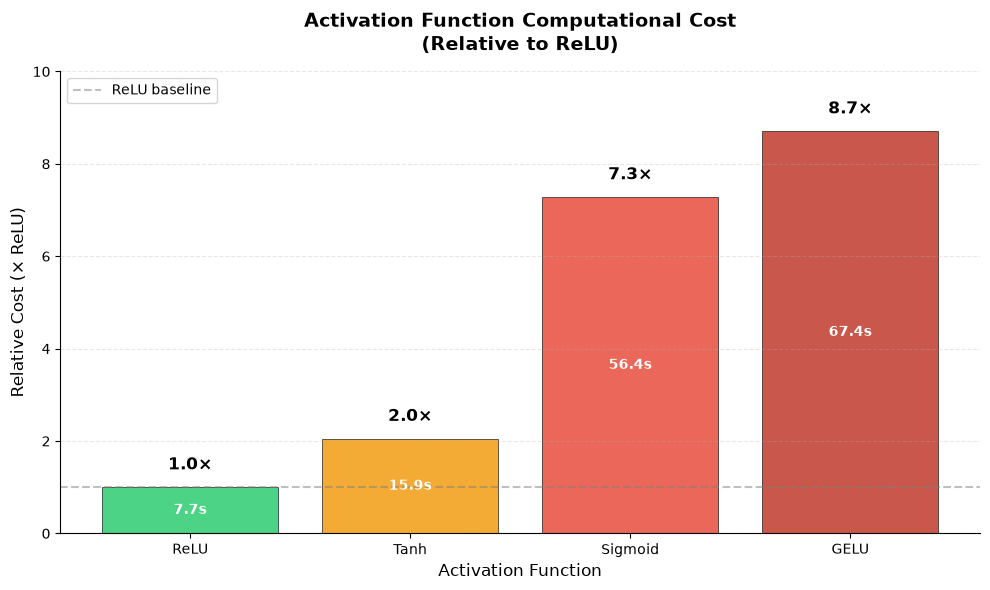

In [23]:
import matplotlib.pyplot as plt

# Measured benchmark results
activations = ["ReLU", "Tanh", "Sigmoid", "GELU"]
times = [7.74, 15.86, 56.35, 67.39]

# Calculate relative cost compared to ReLU
baseline = times[0]
relative_cost = [t / baseline for t in times]

# Color scheme: green for baseline, gradient for others
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']

plt.figure(figsize=(10, 6))

bars = plt.bar(
    activations,
    relative_cost,
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.85
)

# Add values on top of bars
for bar, cost in zip(bars, relative_cost):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.3,
        f'{cost:.1f}×',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Add actual time annotations
for bar, time_val in zip(bars, times):
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height()/2.,
        f'{time_val:.1f}s',
        ha='center',
        va='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

plt.axhline(y=1, linestyle='--', linewidth=1.5, color='gray', alpha=0.5, label='ReLU baseline')

plt.title('Activation Function Computational Cost\n(Relative to ReLU)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Activation Function', fontsize=12)
plt.ylabel('Relative Cost (× ReLU)', fontsize=12)
plt.ylim(0, max(relative_cost) * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='upper left', framealpha=0.8)

# Remove top and right spines for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()